# Introduction to Feature Engineering

**Feature Engineering** is the process of selecting, transforming, and enriching data (sample attributes) to improve the performance of machine learning algorithms used to train models.

## Benefits
1. Improved model accuracy
2. Reduced overfitting
3. Easier interpretation of results
4. More efficient runtime

## Overall Modelling Process

Where does Feature Engineering fit?
```
Raw Data → Data Cleaning → Feature Engineering → Model Training → Evaluation
```
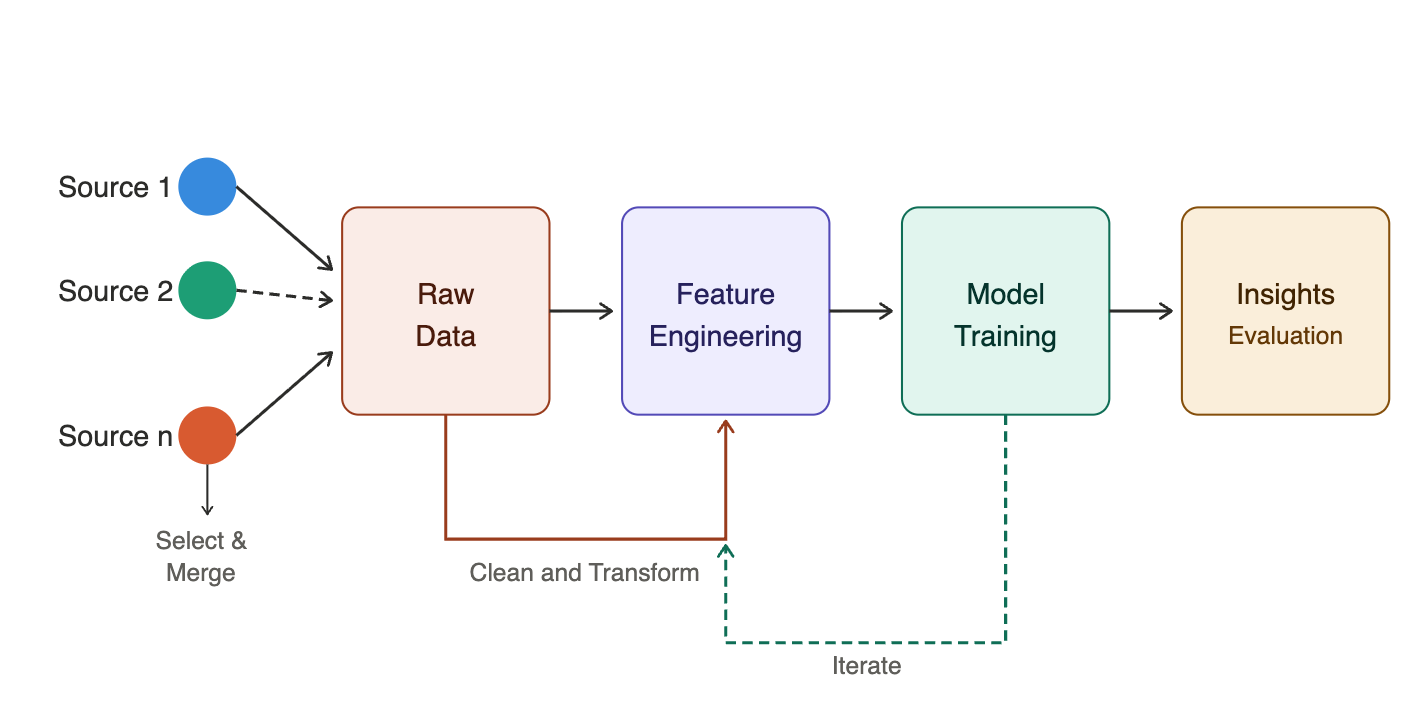

---
# Overview of Techniques

## Imputation

Strategies for filling missing values:
- Column mean, median, or mode
- Matrix completion or other more complicated mechanisms

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Sample data with missing values
df = pd.DataFrame({'A': [1, 2, np.nan, 4], 'B': [5, np.nan, 7, 8]})

# Impute with mean
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed

## Scaling / Normalization

Adjusting features to be on the same scale to avoid distortions when modeling. Scaling also helps with ML runtime performance.

### Two Types

**Normalization** — scales each feature so all values are within range [0, 1]
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Standardization** — transforms each feature to have mean of 0 and std of 1 (z-score)
$$Z = \frac{X - \mu}{\sigma}$$

Standardization is particularly useful when features have varying scales and distributions.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = np.array([[1, 200], [2, 300], [3, 400], [4, 500]])

# Normalization (0 to 1)
normalizer = MinMaxScaler()
data_normalized = normalizer.fit_transform(data)
print("Normalized:\n", data_normalized)

# Standardization (z-score)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)
print("\nStandardized:\n", data_standardized)

## Encoding

For categorical features or where algebraic mappings aren't possible.

### One-Hot Encoding (Dummy Variables)
- Can greatly increase dataset size if many values in a category
- Sparse output can be a potential solution

In [ ]:
from sklearn.feature_extraction import DictVectorizer

data = [{'color': 'red', 'size': 'large'},
        {'color': 'blue', 'size': 'small'},
        {'color': 'green', 'size': 'medium'}]

vec = DictVectorizer(sparse=False)
encoded = vec.fit_transform(data)
print(vec.get_feature_names_out())
print(encoded)

### Text Encoding

Converting text to representative numerical values:
- Text is vectorized where each word gets a column
- Overweighting frequent words can cause distortion → use **TF-IDF** (term frequency-inverse document frequency)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus = ['the cat sat on the mat', 'the dog ran in the park']

# Word counts
count_vec = CountVectorizer()
counts = count_vec.fit_transform(corpus)
print("Features:", count_vec.get_feature_names_out())
print("Counts:\n", counts.toarray())

# TF-IDF
tfidf_vec = TfidfVectorizer()
tfidf = tfidf_vec.fit_transform(corpus)
print("\nTF-IDF:\n", tfidf.toarray())

### Image Encoding

Flattening pixel arrays so each feature represents a pixel in an image.

In [ ]:
# Example: flattening a 28x28 image into 784 features
image = np.random.rand(28, 28)
flattened = image.flatten()
print(f"Original shape: {image.shape}")
print(f"Flattened shape: {flattened.shape}")

## Derived Features

Adding features that represent mathematical derivations from input features.

- Improve a model by transforming inputs, not the method
- Example: adding polynomial features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[2], [3], [4]])

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print("Original:", X.flatten())
print("Polynomial (x, x^2):\n", X_poly)

## Feature Selection & Extraction

Removing dimensions to simplify models.

### Why?
- Easier to interpret and understand relationships with large number of dimensions
- Reduces memory and computing power while maintaining data characteristics
- Helps minimize error rate

### Techniques
- **PCA** (Principal Component Analysis)
- **ICA** (Independent Component Analysis)
- **LDA** (Linear Discriminant Analysis)

### Key Points
- Requires experimentation combined with automated techniques
- Supported by intuition and domain knowledge
- **Feature learning** — where the machine not only uses features for learning but also learns the features itself

In [ ]:
from sklearn.decomposition import PCA

# Sample high-dimensional data
X = np.random.rand(100, 10)

# Reduce to 2 components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")